# Notebook 1: What Is an Encoded Magic State?

**Welcome.** This notebook will take you from a single qubit to a fault-tolerant building block, step by step. Every concept is introduced with motivation first, then code, then a quiz to check your understanding.

### The big picture

In fault-tolerant quantum computing, most logical gates can be implemented transversally using **Clifford operations** (H, S, CNOT). But Cliffords alone are not enough for universal computation. The **Gottesman-Knill theorem** proves that any circuit built only from Clifford gates can be efficiently simulated on a classical computer — no quantum advantage.

To break out of this classical-simulability trap, you need a **non-Clifford resource**. The simplest one is the **T-gate** ($\pi/8$ rotation). But implementing T fault-tolerantly is hard — you cannot do it transversally in most codes. The workaround: prepare a special quantum state called the **magic state**, then consume it to perform the T-gate via gate teleportation.

$$|T\rangle = \frac{|0\rangle + e^{i\pi/4}|1\rangle}{\sqrt{2}}$$

This notebook teaches you to:
1. Build a magic state and see it on the Bloch sphere
2. Understand *why* there are multiple preparation methods and when each matters
3. Encode it into the [[4,2,2]] error-detecting code
4. Verify the encoding using stabilizer algebra
5. See error detection in action — break the state and watch the code catch it
6. Run a full syndrome-measurement simulation with postselection

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, SparsePauliOp, state_fidelity, DensityMatrix
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator

from autoresearch_quantum.codes.four_two_two import (
    build_preparation_circuit,
    build_encoder,
    apply_magic_seed,
    encoded_magic_statevector,
    STABILIZERS,
    MEASUREMENT_OPERATORS,
    DATA_QUBITS,
)
from autoresearch_quantum.experiments.encoded_magic_state import build_circuit_bundle
from autoresearch_quantum.models import ExperimentSpec

print("Imports OK.")

Imports OK.


In [2]:
from autoresearch_quantum.teaching import LearningTracker
from autoresearch_quantum.teaching.assess import quiz, predict_choice, reflect, order, checkpoint_summary

tracker = LearningTracker("plan_a_01")
print("Learning tracker active. Quizzes will appear as interactive widgets.")

Learning tracker active. Quizzes will appear as interactive widgets.


---
## 1. The Single-Qubit Magic State

### Why this state?

Imagine you have a quantum computer that can only do Clifford gates. You can create entanglement, teleport states, do error correction — but you **cannot** solve any problem faster than a classical computer. You are stuck.

The T-state is the key that unlocks universality. By preparing $|T\rangle$ with high fidelity and "injecting" it into your Clifford circuit, you gain the ability to perform the T-gate:

$$T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}$$

The T-state itself is prepared by applying Hadamard followed by a $P(\pi/4)$ phase gate to $|0\rangle$:

$$|T\rangle = P(\pi/4) \cdot H \, |0\rangle = \frac{|0\rangle + e^{i\pi/4}|1\rangle}{\sqrt{2}}$$

Let's build it and look at its amplitudes.

In [3]:
# Build a single-qubit T-state using H then P(pi/4)
qc_single = QuantumCircuit(1, name="T-state")
qc_single.h(0)
qc_single.p(pi / 4, 0)

t_state = Statevector.from_instruction(qc_single)
print("T-state amplitudes:", t_state.data)
print(f"  |0> amplitude: {t_state.data[0]:.4f}")
print(f"  |1> amplitude: {t_state.data[1]:.4f}")
print(f"  |1> phase:     {np.angle(t_state.data[1]):.4f} rad = {np.angle(t_state.data[1]) * 180 / pi:.1f} deg")
print(f"  Expected phase: pi/4 = {pi/4:.4f} rad = 45.0 deg")

T-state amplitudes: [0.70710678+0.j  0.5       +0.5j]
  |0> amplitude: 0.7071+0.0000j
  |1> amplitude: 0.5000+0.5000j
  |1> phase:     0.7854 rad = 45.0 deg
  Expected phase: pi/4 = 0.7854 rad = 45.0 deg


In [4]:
quiz(tracker, "q1_tstate_phase",
    question="What is the phase angle of the |1\u27E9 coefficient in the T-state?",
    options=[
        "\u03C0/2 (90\u00b0)",
        "\u03C0/4 (45\u00b0)",
        "\u03C0/8 (22.5\u00b0)",
        "\u03C0 (180\u00b0)",
    ],
    correct=1,
    section="1. The T-state",
    bloom="remember",
    explanation=(
        "The T-state is \\((|0\\rangle + e^{i\\pi/4}|1\\rangle)/\\sqrt{2}\\). "
        "The phase is \\(\\pi/4 = 45\u00b0\\). "
        "Confusingly, the gate is called T (for \\(\\pi/8\\)) because the Bloch sphere rotation "
        "angle is half the gate phase."
    ))

### The Bloch sphere picture

Every single-qubit pure state can be visualized as a point on the Bloch sphere. The T-state sits at:
- **Polar angle** $\theta = \pi/2$ (on the equator — equal probability of $|0\rangle$ and $|1\rangle$)
- **Azimuthal angle** $\phi = \pi/4$ (45° between the X and Y axes)

This means $\langle X \rangle = \langle Y \rangle = 1/\sqrt{2} \approx 0.707$ and $\langle Z \rangle = 0$.

Stabilizer states ($|0\rangle$, $|+\rangle$, $|i\rangle$, etc.) always sit at the poles or on the axes. The T-state is **between** axes — that's what makes it non-stabilizer and therefore useful.

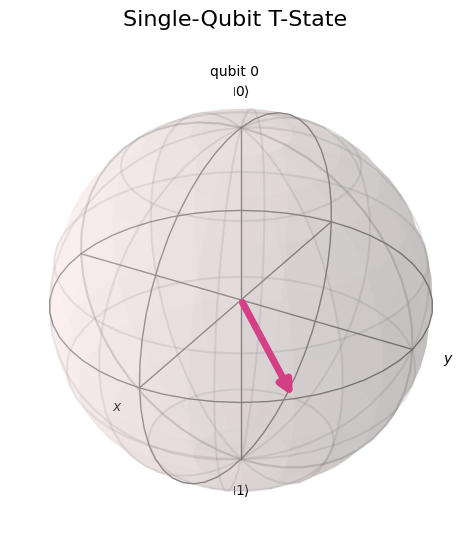


Expectation values:
  <X> = 0.7071
  <Y> = 0.7071
  <Z> = 0.0000


In [5]:
# Visualize on the Bloch sphere
fig = plot_bloch_multivector(t_state, title="Single-Qubit T-State")
plt.show()

# Verify the expectation values numerically
print("\nExpectation values:")
for pauli in ["X", "Y", "Z"]:
    op = SparsePauliOp.from_list([(pauli, 1.0)])
    val = t_state.expectation_value(op).real
    print(f"  <{pauli}> = {val:.4f}")

In [8]:
predict_choice(tracker, "q2_bloch_position",
    question="The T-state Bloch vector: where does it point?",
    options=[
        "North pole (along +Z)",
        "Along the +X axis",
        "On the equator, 45\u00b0 between X and Y",
        "At the south pole (along \u2212Z)",
    ],
    correct=2,
    bloom="understand",
    explanation=(
        "The T-state has equal \u27E8X\u27E9 and \u27E8Y\u27E9 (both 1/\u221A2 \u2248 0.707) "
        "and \u27E8Z\u27E9 = 0, placing it on the equator at azimuthal angle \u03C0/4."
    ))

In [10]:
quiz(tracker, "q3_why_tstate",
    question="Why can't we just use Clifford gates for everything?",
    options=[
        "Clifford gates are too slow on real hardware",
        "Clifford gates cannot create entanglement",
        "Clifford-only circuits can be efficiently simulated classically (Gottesman-Knill theorem)",
        "Clifford gates introduce too many errors",
    ],
    correct=2,
    bloom="understand",
    explanation=(
        "The Gottesman-Knill theorem proves that stabilizer circuits (Cliffords + Pauli measurements + stabilizer inputs) "
        "can be simulated in polynomial time on a classical computer. "
        "Adding a non-Clifford resource like the T-state breaks this and enables quantum advantage."
    ))

checkpoint_summary(tracker, "1. The T-state")

---
## 2. Three Seed Styles — Same State, Different Gates

### Why multiple preparations?

There is more than one way to prepare the T-state. The codebase implements three:

| Style | Gates | Why it exists |
|-------|-------|---------------|
| `h_p` | $H \to P(\pi/4)$ | The textbook definition. Clearest to read. |
| `ry_rz` | $R_y(\pi/2) \to R_z(\pi/4)$ | Uses rotation gates that some hardware supports natively. |
| `u_magic` | $U(\pi/2, \pi/4, 0)$ | Single-gate form. Fewest gates before transpilation. |

**Why does this matter?** Different quantum processors have different **native gate sets**. IBM's processors natively support $\{\sqrt{X}, R_z, CX\}$. When you write `H`, the transpiler decomposes it into native gates. A preparation that uses fewer non-native gates may transpile to a shorter, less noisy circuit.

Let's verify all three produce the same quantum state.

In [11]:
seed_styles = ["h_p", "ry_rz", "u_magic"]
states = {}

for style in seed_styles:
    qc = QuantumCircuit(1, name=style)
    apply_magic_seed(qc, 0, style)
    sv = Statevector.from_instruction(qc)
    states[style] = sv
    print(f"{style:10s}: amplitudes = {sv.data}")

# Compute pairwise fidelities
print()
for s1 in seed_styles:
    for s2 in seed_styles:
        if s1 < s2:
            fid = state_fidelity(states[s1], states[s2])
            print(f"Fidelity({s1}, {s2}) = {fid:.6f}")

h_p       : amplitudes = [0.70710678+0.j  0.5       +0.5j]
ry_rz     : amplitudes = [0.65328148-0.27059805j 0.65328148+0.27059805j]
u_magic   : amplitudes = [0.70710678+0.j  0.5       +0.5j]

Fidelity(h_p, ry_rz) = 1.000000
Fidelity(h_p, u_magic) = 1.000000
Fidelity(ry_rz, u_magic) = 1.000000


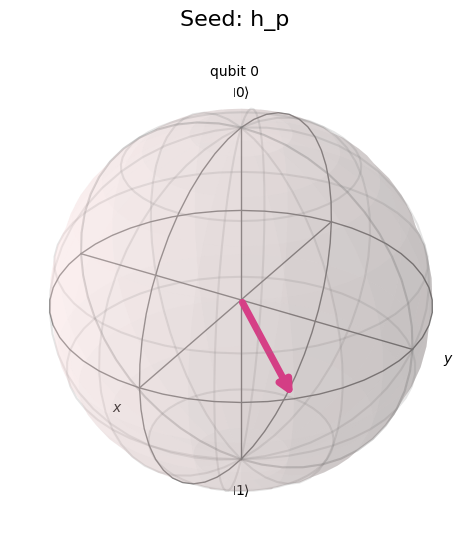

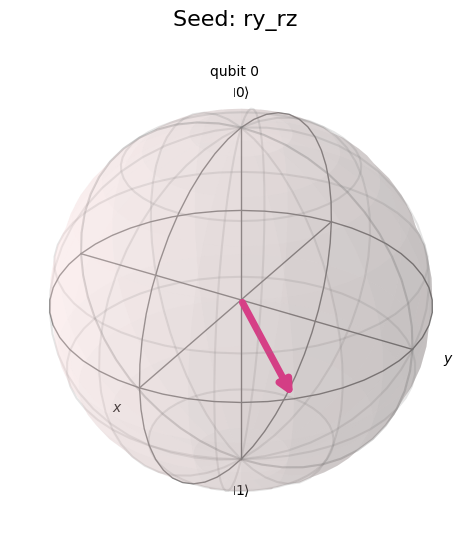

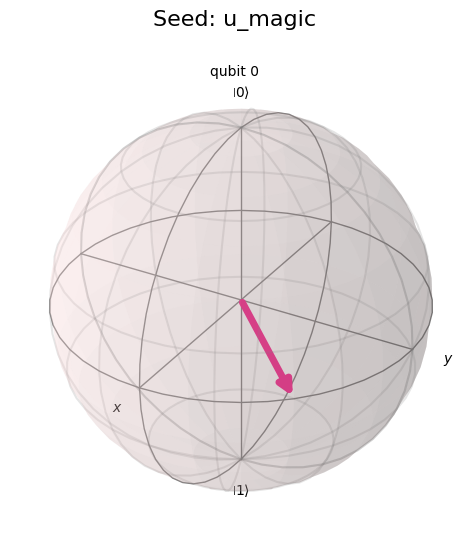

In [12]:
# Bloch sphere for each seed style
for style in seed_styles:
    fig = plot_bloch_multivector(states[style], title=f"Seed: {style}")
    plt.show()

All three fidelities are 1.0 (or extremely close) and the Bloch spheres all point to the same spot. The amplitudes may differ by a **global phase** factor $e^{i\theta}$, which has no physical significance — all measurements yield identical results.

> **Take-away:** The choice of seed style is not about physics (they all give the same state). It is about **engineering**: which one transpiles to the fewest noisy gates on your target hardware?

In [14]:
quiz(tracker, "q4_global_phase",
    question="Two states have different complex amplitudes but fidelity = 1.0. Why?",
    options=[
        "Floating-point rounding errors",
        "A global phase factor has no physical consequence \u2014 only relative phases matter",
        "The Bloch sphere representation is approximate",
    ],
    correct=1,
    section="2. Seed styles",
    bloom="understand",
    explanation=(
        "Multiplying all amplitudes by the same phase factor does not change any measurement outcome. "
        "Two states related by a global phase are physically identical."
    ))

checkpoint_summary(tracker, "2. Seed styles")

---
## 3. Why Encode? The Fragility Problem

### The dilemma

A bare single-qubit T-state is **fragile**. Any noise — bit-flips, phase drifts, measurement crosstalk — corrupts it. And we cannot protect it the way we protect classical data:

- **No cloning**: Quantum mechanics forbids copying an unknown quantum state.
- **No majority vote**: We cannot make 3 copies and take the majority.
- **Measurement destroys**: Reading the state to check it collapses the superposition.

The solution is **quantum error correction**: encode the logical qubit into multiple physical qubits in a way that errors can be detected (or corrected) without revealing the logical information.

### The [[4,2,2]] code

The **[[4,2,2]]** code is one of the smallest useful quantum codes:
- **4** physical qubits
- **2** logical qubits (one for the T-state, one "spectator" in $|0\rangle_L$)
- **Distance 2**: can **detect** any single-qubit error, but cannot correct it

What "distance 2" means concretely: if **one** qubit suffers an error (X, Y, or Z), the code's stabilizer measurements will flag it. The strategy is **postselection**: discard any shot where an error was detected, and keep only the clean shots.

This is a trade-off: you lose some shots (reduced acceptance rate) but the surviving shots have higher quality. Whether this trade-off is worthwhile depends on the noise level — we'll explore this quantitatively in Notebook 2.

In [16]:
quiz(tracker, "q5_distance_2",
    question='The [[4,2,2]] code has distance 2. What does this mean in practice?',
    options=[
        "It can correct any 1-qubit error",
        "It can detect any 1-qubit error but not correct it",
        "It can detect any 2-qubit error",
        "It uses 2 ancilla qubits",
    ],
    correct=1,
    section="3. Why encode",
    bloom="remember",
    explanation=(
        "Distance d means the code can detect up to d\u22121 errors. "
        "Distance 2 \u2192 detects 1-qubit errors. "
        "Correction requires distance \u2265 3. "
        "The [[4,2,2]] code uses detection + postselection instead of correction."
    ))

In [17]:
quiz(tracker, "q6_no_cloning",
    question="Why can't we protect a qubit by simply making backup copies?",
    options=[
        "Quantum hardware doesn't support the COPY gate yet",
        "The no-cloning theorem forbids copying an unknown quantum state",
        "Copies would entangle with the original and cause errors",
    ],
    correct=1,
    bloom="understand",
    explanation=(
        "The no-cloning theorem (Wootters & Zurek, 1982) is a fundamental result: "
        "there is no quantum operation that can copy an arbitrary unknown state. "
        "This is why quantum error correction works so differently from classical error correction \u2014 "
        "it encodes information into entanglement patterns rather than redundant copies."
    ))

checkpoint_summary(tracker, "3. Why encode")

---
## 4. Building the Encoder Step by Step

### What the encoder does

The encoder takes 4 qubits in the state $|T\rangle|0\rangle|0\rangle|0\rangle$ and entangles them into a 4-qubit codeword. After encoding, **no single qubit carries the T-state information** — it is distributed across all four qubits. This redundancy is what enables error detection.

The `cx_chain` encoder uses 5 CNOT gates and 1 Hadamard:

cx_chain encoder circuit:


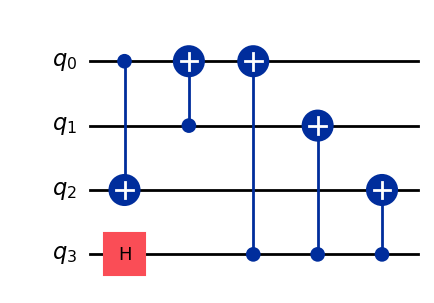

In [18]:
# Build and display the cx_chain encoder
encoder_cx = build_encoder("cx_chain")
print("cx_chain encoder circuit:")
fig = encoder_cx.draw('mpl', style='iqp')
plt.show()

### Reading the circuit

| Step | Gate | What it does |
|------|------|-------------|
| 1 | CNOT(0, 2) | Spreads qubit 0's state to qubit 2 — begins creating the logical $X_L = X_0 X_2$ structure |
| 2 | CNOT(1, 0) | Entangles the spectator qubit 1 with qubit 0 |
| 3 | H(3) | Puts qubit 3 in superposition $|+\rangle$ |
| 4-6 | CNOT(3, 0), CNOT(3, 1), CNOT(3, 2) | Qubit 3 fans out to all others, creating the $XXXX$ stabilizer structure |

The CNOTs create **entanglement** between the qubits. After step 6, measuring any single qubit gives a random outcome — but measuring the **parity** of all four (the stabilizer) gives a deterministic result.

In [20]:
quiz(tracker, "q7_gate_count",
    question="How many 2-qubit (CNOT) gates are in the cx_chain encoder?",
    options=["3", "4", "5", "6"],
    correct=2,
    section="4. Encoder circuit",
    bloom="apply",
    explanation=(
        "CX(0,2), CX(1,0), CX(3,0), CX(3,1), CX(3,2) = 5 CNOT gates. "
        "Two-qubit gates are the noisiest operations on real hardware, so this count "
        "is the primary driver of circuit cost."
    ))

---
## 5. Full Preparation Circuit

The complete preparation is: **seed** (T-state on qubit 0) followed by **encoder** (spread across all 4 qubits).

### What to expect

A 4-qubit system has $2^4 = 16$ possible basis states ($|0000\rangle$ through $|1111\rangle$). But the encoded T-state only occupies a small subspace — the **codespace** of the [[4,2,2]] code. We expect only a few basis states to have non-zero amplitude.

In [22]:
predict_choice(tracker, "q8_nonzero_amplitudes",
    question="How many of the 16 basis states will have non-zero amplitude in the encoded T-state?",
    options=["2 (just |0000\u27E9 and |1111\u27E9)", "4", "8", "All 16"],
    correct=1,
    section="5. Encoded state",
    bloom="understand",
    explanation=(
        "The [[4,2,2]] codespace has 4 basis codewords (2 logical qubits \u2192 2\u00b2 = 4 states). "
        "The T-state is a superposition of |0\u27E9_L and |1\u27E9_L, each mapping to 2 physical states, "
        "giving exactly 4 non-zero amplitudes."
    ))

Preparation circuit: 4 qubits, depth 7


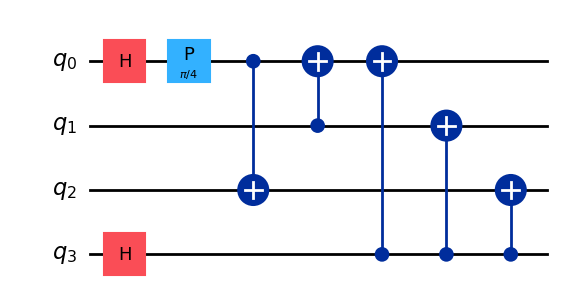

In [23]:
# Full preparation circuit
prep = build_preparation_circuit(seed_style="h_p", encoder_style="cx_chain")
print(f"Preparation circuit: {prep.num_qubits} qubits, depth {prep.depth()}")
fig = prep.draw('mpl', style='iqp')
plt.show()

In [24]:
# Compute the encoded statevector
encoded_sv = Statevector.from_instruction(prep)
print(f"Statevector has {len(encoded_sv.data)} amplitudes (2^{prep.num_qubits} = {2**prep.num_qubits})")
print("\nNon-zero amplitudes:")
for i, amp in enumerate(encoded_sv.data):
    if abs(amp) > 1e-10:
        binary = format(i, f'0{prep.num_qubits}b')
        print(f"  |{binary}> : {amp:.4f}  (magnitude: {abs(amp):.4f})")

Statevector has 16 amplitudes (2^4 = 16)

Non-zero amplitudes:
  |0000> : 0.5000+0.0000j  (magnitude: 0.5000)
  |0101> : 0.3536+0.3536j  (magnitude: 0.5000)
  |1010> : 0.3536+0.3536j  (magnitude: 0.5000)
  |1111> : 0.5000+0.0000j  (magnitude: 0.5000)


### Interpreting the output

You should see exactly **4** non-zero amplitudes: $|0000\rangle$, $|0101\rangle$, $|1010\rangle$, $|1111\rangle$. These are the codewords of the [[4,2,2]] code. Notice:
- All four have the **same magnitude** (0.5) — equal probability
- The **phases** encode the T-state information (the $e^{i\pi/4}$ factor appears on $|0101\rangle$ and $|1010\rangle$)
- No single qubit's measurement alone reveals the T-state — the information lives in the *correlations* between qubits

In [25]:
checkpoint_summary(tracker, "5. Encoded state")

---
## 6. Stabilizer Verification — The Quantum Checksum

### What are stabilizers?

A **stabilizer** is an operator that leaves the code's valid states unchanged. For the [[4,2,2]] code, the two stabilizers are:

$$XXXX = X \otimes X \otimes X \otimes X \quad\text{and}\quad ZZZZ = Z \otimes Z \otimes Z \otimes Z$$

A valid codeword $|\psi\rangle$ satisfies:
$$XXXX|\psi\rangle = +|\psi\rangle \quad\text{and}\quad ZZZZ|\psi\rangle = +|\psi\rangle$$

In terms of expectation values: $\langle XXXX \rangle = +1$ and $\langle ZZZZ \rangle = +1$.

Think of this as a **checksum**: just as a classical checksum detects corrupted data, the stabilizer eigenvalue detects corrupted quantum states. If an error occurs, at least one stabilizer flips to $-1$.

In [26]:
# Compute stabilizer expectation values
for name, operator in STABILIZERS.items():
    expectation = encoded_sv.expectation_value(operator)
    print(f"<{name}> = <{operator.to_list()[0][0]}> = {expectation.real:+.6f}")

print("\nBoth stabilizers should be +1.0 for a valid codeword.")

<z_stabilizer> = <ZZZZ> = +1.000000
<x_stabilizer> = <XXXX> = +1.000000

Both stabilizers should be +1.0 for a valid codeword.


In [27]:
quiz(tracker, "q9_stabilizer_meaning",
    question="What does it mean when \u27E8ZZZZ\u27E9 = +1?",
    options=[
        "All four qubits are in the |0\u27E9 state",
        "The state is in the codespace \u2014 no X-type error has been detected",
        "The Z-gate has been applied to all four qubits",
        "The state has zero energy",
    ],
    correct=1,
    section="6. Stabilizers",
    bloom="understand",
    explanation=(
        "\u27E8ZZZZ\u27E9 = +1 means the state is an eigenstate of ZZZZ with eigenvalue +1. "
        "This is the codespace condition. If a single X-error occurs on any qubit, "
        "ZZZZ anti-commutes with that X, flipping the eigenvalue to \u22121."
    ))

In [ ]:
quiz(tracker, "q10_which_detects_what",
    question="A single Z error on qubit 3 occurs. Which stabilizer detects it?",
    options=[
        "ZZZZ (because Z commutes with Z, so ZZZZ stays at +1) \u2014 wait, that means ZZZZ does NOT detect it",
        "XXXX detects it (because Z anti-commutes with X)",
        "Both XXXX and ZZZZ detect it",
        "Neither \u2014 Z errors are undetectable",
    ],
    correct=1,
    bloom="apply",
    explanation=(
        "Z commutes with Z (ZZ = ZZ), so ZZZZ is unaffected by a Z error. "
        "But Z anti-commutes with X (ZX = \u2212XZ), so XXXX flips to \u22121. "
        "Rule of thumb: X-errors are caught by the Z-stabilizer, and Z-errors by the X-stabilizer."
    ))

checkpoint_summary(tracker, "6. Stabilizers")

---
## 7. Error Detection in Action — Break It on Purpose

### The experiment

Let's deliberately inject errors and watch the stabilizers respond. We'll apply X (bit-flip), Z (phase-flip), and Y (both) errors on every qubit.

**Prediction guide** before you run the next cell:
- An **X error** on any qubit: $X_j$ anti-commutes with $Z_j$ in $ZZZZ$, so $ZZZZ$ flips to $-1$. $XXXX$ is unaffected.
- A **Z error** on any qubit: $Z_j$ anti-commutes with $X_j$ in $XXXX$, so $XXXX$ flips to $-1$. $ZZZZ$ is unaffected.
- A **Y error** ($Y = iXZ$): both stabilizers flip to $-1$.

In [ ]:
predict_choice(tracker, "q11_y_error_prediction",
    question="A Y error on qubit 2: how many stabilizers will flip to \u22121?",
    options=["0 \u2014 Y errors are undetectable", "1 \u2014 either XXXX or ZZZZ", "2 \u2014 both XXXX and ZZZZ"],
    correct=2,
    section="7. Error detection",
    bloom="understand",
    explanation=(
        "Y = iXZ contains both an X-part and a Z-part. "
        "The X-part is caught by ZZZZ and the Z-part by XXXX. "
        "Both stabilizers flip \u2192 Y errors have the most distinctive syndrome signature."
    ))

In [ ]:
# Single error example: X on qubit 1
error_circuit = prep.copy()
error_circuit.x(1)
corrupted_sv = Statevector.from_instruction(error_circuit)

print("Stabilizers AFTER X error on qubit 1:")
for name, operator in STABILIZERS.items():
    expectation = corrupted_sv.expectation_value(operator)
    status = "PASS" if abs(expectation.real - 1.0) < 1e-6 else "FAIL (error detected!)"
    print(f"  <{operator.to_list()[0][0]}> = {expectation.real:+.6f}  [{status}]")

print("\nCompare with the error-free case:")
for name, operator in STABILIZERS.items():
    expectation = encoded_sv.expectation_value(operator)
    print(f"  <{operator.to_list()[0][0]}> = {expectation.real:+.6f}  [PASS]")

In [ ]:
# Complete error detection table
print("Error detection summary:")
print(f"{'Error':>12s} | {'<XXXX>':>8s} | {'<ZZZZ>':>8s} | Detected by")
print("-" * 55)

for qubit in range(4):
    for error_name, error_gate in [("X", "x"), ("Z", "z"), ("Y", "y")]:
        err_circ = prep.copy()
        getattr(err_circ, error_gate)(qubit)
        err_sv = Statevector.from_instruction(err_circ)
        xxxx = err_sv.expectation_value(STABILIZERS["x_stabilizer"]).real
        zzzz = err_sv.expectation_value(STABILIZERS["z_stabilizer"]).real
        detected_by = []
        if abs(xxxx - 1.0) > 0.01:
            detected_by.append("XXXX")
        if abs(zzzz - 1.0) > 0.01:
            detected_by.append("ZZZZ")
        print(f"{error_name}(q{qubit}):     | {xxxx:+.4f}   | {zzzz:+.4f}   | {', '.join(detected_by) or 'none'}")

### Reading the table

Every single-qubit error is caught by at least one stabilizer:

| Error type | Caught by | Reason |
|-----------|-----------|--------|
| X (bit-flip) | ZZZZ | X anti-commutes with Z |
| Z (phase-flip) | XXXX | Z anti-commutes with X |
| Y (both) | XXXX and ZZZZ | Y = iXZ, so both parts are caught |

This is the **distance-2 guarantee**: the code detects all weight-1 errors. A weight-2 error (two qubits affected simultaneously) could go undetected — that's the limitation of distance 2.

In [ ]:
order(tracker, "q12_error_ranking",
    instruction="Sort error types by number of stabilizers they trigger (fewest \u2192 most):",
    items=["X", "Z", "Y"],
    correct_order=["X", "Z", "Y"],
    bloom="analyze",
    explanation=(
        "X and Z each trigger exactly 1 stabilizer (tied). "
        "Y triggers 2. So the order is X=Z < Y. "
        "(X and Z are interchangeable in this ranking.)"
    ),
    ties=[["X", "Z"]])

checkpoint_summary(tracker, "7. Error detection")

---
## 8. Comparing Encoder Styles

### Why two encoders?

Just as there are multiple seed styles, there are multiple ways to build the encoder circuit. The project implements:

| Style | Native gates | Pre-transpilation depth |
|-------|-------------|------------------------|
| `cx_chain` | CNOT (CX) | 7 |
| `cz_compiled` | CZ (controlled-Z) | 11 |

Both produce the **exact same** logical state. The choice matters after **transpilation**: if your hardware natively supports CZ gates, then `cz_compiled` may actually be *shorter* after transpilation than `cx_chain` (which would need each CNOT decomposed into CZ + Hadamard pairs).

In [ ]:
# Compare the two encoder styles
encoder_cz = build_encoder("cz_compiled")
print("cz_compiled encoder circuit:")
fig = encoder_cz.draw('mpl', style='iqp')
plt.show()

In [ ]:
# Verify both encoders produce the same state
prep_cx = build_preparation_circuit("h_p", "cx_chain")
prep_cz = build_preparation_circuit("h_p", "cz_compiled")

sv_cx = Statevector.from_instruction(prep_cx)
sv_cz = Statevector.from_instruction(prep_cz)

fid = state_fidelity(sv_cx, sv_cz)
print(f"Fidelity between cx_chain and cz_compiled: {fid:.6f}")
print(f"cx_chain depth: {prep_cx.depth()}, cz_compiled depth: {prep_cz.depth()}")

In [ ]:
reflect(tracker, "q13_encoder_tradeoff",
    question="The cz_compiled encoder has depth 11 vs cx_chain's depth 7. When might you prefer the deeper circuit?",
    section="8. Encoder comparison",
    bloom="evaluate",
    model_answer=(
        "If the hardware natively supports CZ gates (like many superconducting processors), "
        "cx_chain would need each CNOT decomposed into CZ + Hadamard pairs, "
        "potentially making it deeper AFTER transpilation. "
        "The lesson: pre-transpilation depth is misleading. "
        "What matters is depth after transpilation to the hardware's native gate set."
    ))

---
## 9. Verification Circuits with Ancilla Qubits

### The measurement problem

We just computed $\langle ZZZZ \rangle$ and $\langle XXXX \rangle$ using the full statevector. But on a real quantum computer, we don't have access to the statevector — we can only **measure** qubits.

**The catch:** If we measure the 4 data qubits directly, the measurement collapses the superposition and **destroys** the encoded state. We'd learn the stabilizer value, but the T-state would be gone.

### The solution: ancilla qubits

Instead, we use **ancilla** (helper) qubits. The idea:
1. Prepare an ancilla qubit in $|0\rangle$
2. Apply controlled gates between the ancilla and each data qubit to transfer the stabilizer's **parity** onto the ancilla
3. Measure **only the ancilla** — the data qubits remain untouched

The ancilla measurement result (0 or 1) tells us the stabilizer eigenvalue ($+1$ or $-1$) without collapsing the data qubits. This is called **syndrome extraction**.

The result is a **syndrome** bitstring. For our code with two stabilizers, the syndrome is 2 bits:
- `00` → both stabilizers +1 → no error detected → **keep this shot**
- Anything else → error detected → **discard this shot** (postselection)

In [ ]:
# Build the full circuit bundle for a standard experiment
spec = ExperimentSpec(
    rung=1,
    seed_style="h_p",
    encoder_style="cx_chain",
    verification="both",
    postselection="all_measured",
    ancilla_strategy="dedicated_pair",
    shots=256,
    repeats=1,
)

bundle = build_circuit_bundle(spec)
print(f"Bundle contains:")
print(f"  prep circuit:     {bundle.prep.num_qubits} qubits (data only)")
print(f"  acceptance circuit: {bundle.acceptance.num_qubits} qubits ({DATA_QUBITS} data + {bundle.acceptance.num_qubits - DATA_QUBITS} ancilla)")
print(f"  witness circuits: {list(bundle.witness_circuits.keys())}")

In [ ]:
# Show the acceptance circuit
print("Acceptance circuit (syndrome extraction + data readout):")
print(f"  Classical registers: {[creg.name + f'[{creg.size}]' for creg in bundle.acceptance.cregs]}")
fig = bundle.acceptance.draw('mpl', style='iqp')
plt.show()

### Reading the acceptance circuit

The circuit has two **classical registers**:
- **syndrome** [2 bits]: Results from ancilla measurements. Bit 0 = $ZZZZ$ check, bit 1 = $XXXX$ check.
- **readout** [4 bits]: Results from measuring the data qubits.

In the circuit diagram, look for:
- The **ancilla qubits** (extra qubits above/below the data register)
- **Controlled gates** connecting ancillas to data qubits (these extract the parity)
- **Measurement gates** (the meter symbol) on the ancillas and data qubits

In [ ]:
quiz(tracker, "q14_ancilla_purpose",
    question="Why can't we just measure the 4 data qubits to check the stabilizers?",
    options=[
        "We can, but ancillas make it faster",
        "Direct measurement collapses the superposition and destroys the encoded state",
        "The stabilizer operators are not physical observables",
    ],
    correct=1,
    section="9. Verification circuits",
    bloom="understand",
    explanation=(
        "Measuring individual qubits in the Z basis projects them into |0\u27E9 or |1\u27E9, "
        "destroying the superposition that encodes the T-state. "
        "Ancilla-based syndrome extraction reads the stabilizer eigenvalue "
        "without disturbing the logical information."
    ))

In [ ]:
# Show a witness circuit (logical_x)
print("Logical X witness circuit:")
print(f"  Measures operator: {MEASUREMENT_OPERATORS['logical_x']}")
fig = bundle.witness_circuits["logical_x"].draw('mpl', style='iqp')
plt.show()

In [ ]:
quiz(tracker, "q15_three_circuits",
    question="The bundle has 3 witness circuits (logical_x, logical_y, spectator_z). Why not measure all operators in one circuit?",
    options=[
        "The operators don't commute \u2014 measuring one would disturb the others",
        "It would require too many qubits",
        "The simulator can only handle one operator at a time",
    ],
    correct=0,
    bloom="analyze",
    explanation=(
        "Logical X (X\u2080X\u2082) and Logical Y (Y\u2080Z\u2081X\u2082) do not commute. "
        "Measuring one changes the state in a way that invalidates the other measurement. "
        "So each must be measured on a separate, independently prepared copy of the state."
    ))

checkpoint_summary(tracker, "9. Verification circuits")

---
## 10. Running an Ideal Simulation

### What to expect

In a **noiseless** simulation, the state is always in the codespace. That means:
- Both stabilizers always return +1
- Syndrome is always `00`
- **Every** shot passes postselection → acceptance rate = 100%

This is our baseline. Real hardware will be much noisier.

In [ ]:
# Run on ideal AerSimulator
sim = AerSimulator()
shots = 512

result = sim.run(bundle.acceptance, shots=shots).result()
counts = result.get_counts()

print(f"Ran {shots} shots on ideal simulator.")
print(f"Number of distinct outcomes: {len(counts)}")
print(f"\nRaw counts (syndrome + readout):")
for bitstring, count in sorted(counts.items(), key=lambda x: -x[1]):
    parts = bitstring.split(" ")
    if len(parts) == 2:
        syndrome, readout = parts[0], parts[1]
    else:
        syndrome, readout = "", parts[0]
    print(f"  syndrome={syndrome} readout={readout} : {count} shots ({100*count/shots:.1f}%)")

In [ ]:
quiz(tracker, "q16_ideal_acceptance",
    question="In the ideal simulation above, what fraction of shots have syndrome = '00'?",
    options=["About 25%", "About 50%", "About 75%", "100%"],
    correct=3,
    section="10. Ideal simulation",
    bloom="understand",
    explanation=(
        "With no noise, the state never leaves the codespace. "
        "Every stabilizer measurement returns +1, giving syndrome 00 on every shot."
    ))

In [ ]:
# Visualize
fig = plot_histogram(counts, figsize=(12, 5), title="Ideal Simulation: Syndrome + Readout")
plt.show()

---
## 11. Postselection — Keeping Only the Good Shots

### The idea

**Postselection** is a filter: after collecting all measurement results, we look at the syndrome bits and **discard** any shot where the syndrome indicates an error was detected.

In the ideal case (above), this filter has no effect — all shots pass. But under noise (Notebook 2), many shots will fail the syndrome check. The trade-off:

| | Without postselection | With postselection |
|---|---|---|
| **Shots used** | All | Only syndrome = "00" |
| **Quality** | Lower (includes error-corrupted shots) | Higher (only clean shots) |
| **Statistical power** | More data points | Fewer data points |
| **Cost** | Lower | Higher (need more total shots for same statistics) |

The scoring formula in this project captures this tension directly:

$$\text{score} = \frac{\text{quality} \times \text{acceptance\_rate}}{\text{cost}}$$

In [ ]:
from autoresearch_quantum.execution.analysis import (
    postselection_passes, local_memory_records, summarize_context,
)

# Run with memory to access individual shot records
shots = 1024
sim = AerSimulator()
result = sim.run(bundle.acceptance, shots=shots, memory=True).result()
memory = result.get_memory(bundle.acceptance)

# Parse into structured records
records = local_memory_records(memory, [creg.name for creg in bundle.acceptance.cregs])
syndrome_labels = bundle.acceptance.metadata.get("syndrome_labels", [])
postselection_rule = bundle.acceptance.metadata.get("postselection", "all_measured")

summary = summarize_context(records, syndrome_labels, postselection_rule)

print(f"Total shots:      {summary['total_shots']}")
print(f"Accepted shots:   {summary['accepted_shots']}")
print(f"Acceptance rate:  {summary['acceptance_rate']:.4f}")
print(f"\nSyndrome distribution:")
for syndrome, count in sorted(summary['syndrome_counts'].items()):
    pct = count / summary['total_shots'] * 100
    label = "PASS" if all(b == '0' for b in syndrome) else "FAIL"
    print(f"  syndrome={syndrome}  count={count:4d}  ({pct:5.1f}%)  [{label}]")

In [ ]:
quiz(tracker, "q17_postselection_cost",
    question="What is the fundamental cost of postselection?",
    options=[
        "It makes the circuit deeper and noisier",
        "It throws away shots, reducing the amount of usable data",
        "It introduces classical computation overhead",
        "It requires extra qubits",
    ],
    correct=1,
    section="11. Postselection",
    bloom="understand",
    explanation=(
        "Postselection discards shots where errors were detected. "
        "Fewer usable shots means worse statistics or more total shots needed. "
        "This is why acceptance_rate appears in the scoring formula \u2014 "
        "a code that rejects 90% of shots must produce 10x the quality to break even."
    ))

checkpoint_summary(tracker, "11. Postselection")

---
## 12. Summary

In this notebook you learned:

| Concept | What you now know |
|---------|------------------|
| **T-state** | The non-Clifford resource $|T\rangle = (|0\rangle + e^{i\pi/4}|1\rangle)/\sqrt{2}$ needed for universal QC |
| **Seed styles** | Three equivalent gate sequences (h_p, ry_rz, u_magic) — same physics, different engineering trade-offs |
| **[[4,2,2]] code** | 4 physical qubits, 2 logical qubits, distance 2 — detects but doesn't correct single errors |
| **Stabilizers** | XXXX and ZZZZ act as quantum checksums — eigenvalue +1 means "no error" |
| **Error detection** | X→caught by ZZZZ, Z→caught by XXXX, Y→caught by both |
| **Ancilla qubits** | Allow syndrome extraction without destroying the encoded state |
| **Postselection** | Discard error-flagged shots to improve quality at the cost of acceptance rate |

**Next up (Notebook 2):** What happens when we add realistic noise? How bad does it get? And how do we measure whether the encoding actually *helped*? We'll introduce the magic witness formula, the full scoring function, and explore how noise degrades each metric.

---
## Final Assessment

In [ ]:
tracker.dashboard()
path = tracker.save()
print(f"\nProgress saved to: {path}")